In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap

In [4]:
df = pd.read_csv("/content/diabetes_binary_health_indicators_BRFSS2015 (1).csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


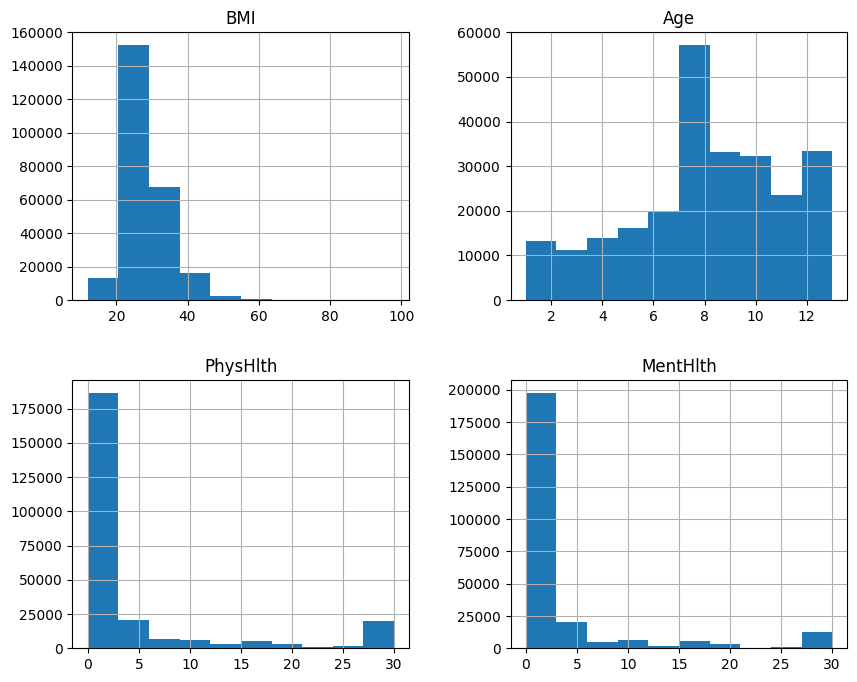

In [5]:
cols = ["BMI", "Age", "PhysHlth", "MentHlth"]
df[cols].hist(figsize=(10,8))
plt.show()

In [6]:
continuous_features = [col for col in df.columns if df[col].nunique() > 15]

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

feature selection

In [7]:
features = [
    'GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol',
    'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'MentHlth', 'Income'
]

In [8]:
X = df[features]
y = df["Diabetes_binary"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

preprocessing

In [10]:
imputer = SimpleImputer(strategy='mean')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features)

SMOTE

In [11]:
sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

random forest model

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [13]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.7881583096814885
ROC AUC: 0.8111518920555993
Recall: 0.612675060121658


In [15]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.82      0.87     43667
         1.0       0.35      0.61      0.45      7069

    accuracy                           0.79     50736
   macro avg       0.64      0.71      0.66     50736
weighted avg       0.85      0.79      0.81     50736



In [16]:
cm = confusion_matrix(y_test, y_pred)

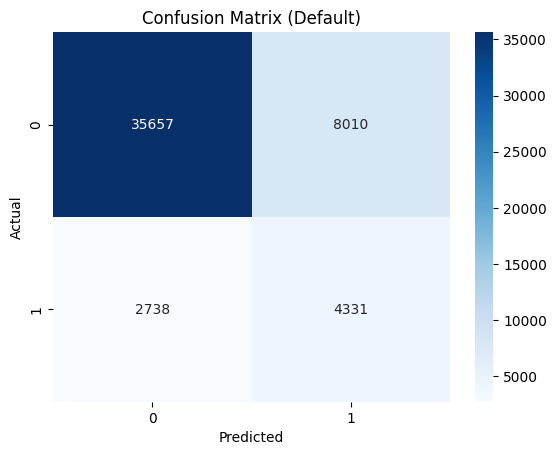

In [17]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Default)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
importances = model.feature_importances_

In [19]:
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

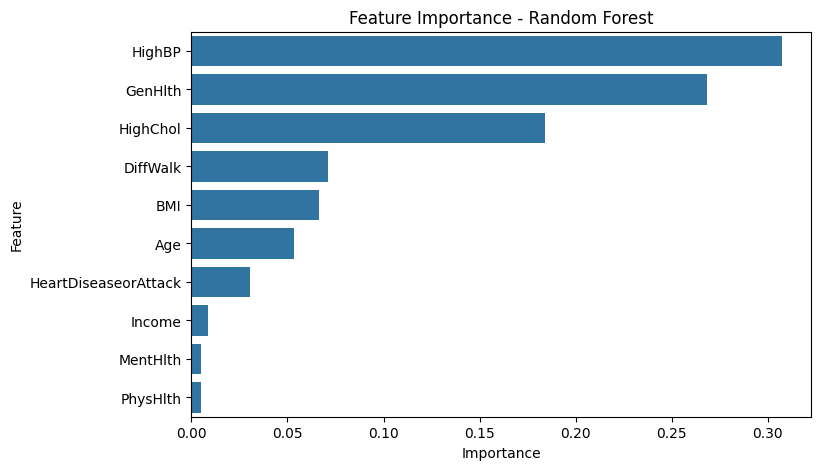

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance - Random Forest")
plt.show()

In [21]:
print("Feature Importance:\n", feat_df)

Feature Importance:
                 Feature  Importance
1                HighBP    0.307376
0               GenHlth    0.268642
4              HighChol    0.183933
3              DiffWalk    0.071034
2                   BMI    0.066236
5                   Age    0.053442
6  HeartDiseaseorAttack    0.030545
9                Income    0.008493
8              MentHlth    0.005208
7              PhysHlth    0.005092


In [22]:
# SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap_values_class1 = shap_values[:, :, 1]

100%|===================| 101462/101472 [54:28<00:00]       

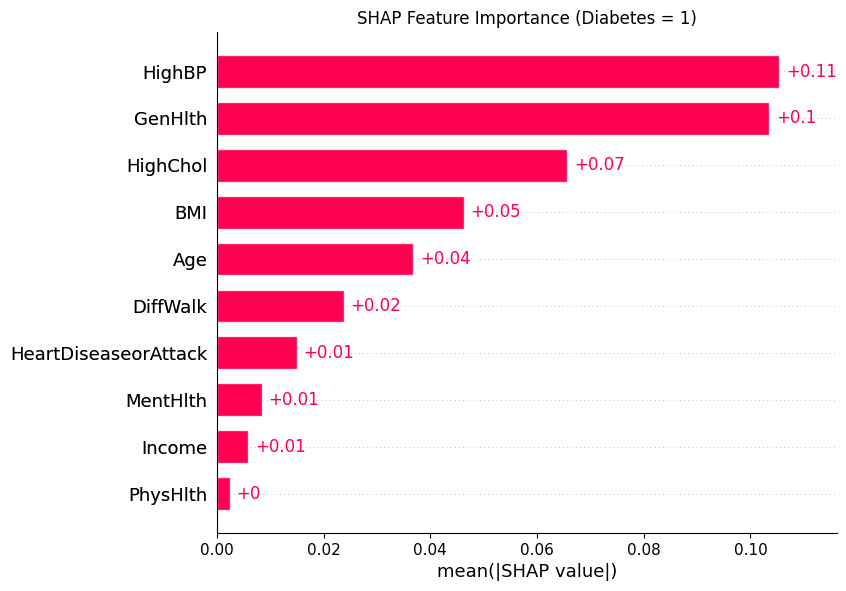

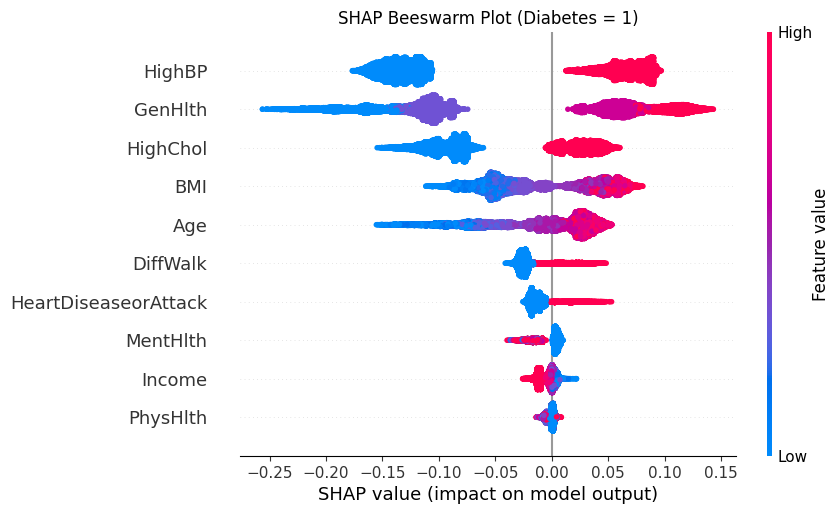

In [23]:
# Plots
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(12,6))
shap.plots.bar(shap_values_class1, show=False)
plt.title("SHAP Feature Importance (Diabetes = 1)")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12,6))
shap.plots.beeswarm(shap_values_class1, show=False)
plt.title("SHAP Beeswarm Plot (Diabetes = 1)")
plt.show()